<a href="https://colab.research.google.com/github/Eng-NadeenShadeed/BinX_AI_ML_Internship/blob/main/Week7/Day%203/day3_rnn_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 · Day 3 — RNNs & LSTMs
**BinX Tech — AI & ML Internship**

Sequence Modeling — ECG Heartbeat Classification

---

## Connecting to What We Learned

Over the past two days, I worked with two types of data and two architectures:

| Week | Data Type | Architecture | Why |
|------|-----------|-------------|-----|
| Week 6 | Tabular (clinical features) | Dense Network | Features are independent — no spatial or sequential structure |
| Week 7 Day 2 | Images (melanoma) | CNN | Pixels are spatially related — patterns shift across the image |
| Week 7 Day 3 | Sequential (ECG signals) | RNN / LSTM | Each value depends on what came before — order carries meaning |

The pattern is always the same: **the data type determines the architecture.**

CNNs exploit spatial structure. Dense Networks handle independent features.
Today I add the third piece — architectures designed for data where
**time and order matter.**

---

## Different Data → Different Architectures

So far I have seen two problems with Dense Networks on structured data:

**Problem 1 — Images (Day 2):**
A Dense Network ignores that nearby pixels are related.
Solution → CNN: slides a filter across spatial positions.

**Problem 2 — Sequences (Today):**
A Dense Network ignores that elements have an order and each one
depends on what came before.
Solution → RNN/LSTM: processes elements one at a time, carrying
memory of previous elements forward.

The ECG dataset contains heartbeat signals — 187 time steps per heartbeat.
Each value in the signal depends on the values before it.
A Dense Network would see 187 independent numbers.
An LSTM sees a sequence unfolding over time.

---

## What Is Sequential Data?

Sequential data is any data where the **order of elements carries meaning**.
Changing the order changes the information — or destroys it entirely.

| Data Type | Example | Why Order Matters |
|-----------|---------|------------------|
| Text | "The movie was not good" | Shuffle the words → meaning disappears |
| ECG signal | Heartbeat waveform | Shuffle the time steps → medical pattern disappears |
| Audio | Speech recording | Shuffle the samples → noise |
| Stock prices | Daily closing prices | Shuffle the days → trend disappears |
| Video | Frames of a action | Shuffle the frames → story disappears |

The cardiovascular tabular data from Week 6 was **not** sequential —
Age, Cholesterol, and BloodPressure have no meaningful order between them.
ECG signals **are** sequential — each millisecond of the signal
depends on the milliseconds before it.

---

## Why Does Order Matter?

Consider a simple example with text:

- "The movie was **not** good" → Negative sentiment
- "The movie was good, **not** bad" → Positive sentiment

The word "not" means completely different things depending on what
comes before and after it. A Dense Network sees a bag of words —
it counts which words appear but ignores their positions.
An RNN reads left to right, remembering context as it goes.

For ECG signals, the same logic applies:
- A normal heartbeat has a specific wave shape — P wave, QRS complex, T wave —
  that unfolds over time in a specific order
- An abnormal heartbeat disrupts that order or shape
- A model that ignores time cannot detect these patterns reliably

**Visual Experiment**

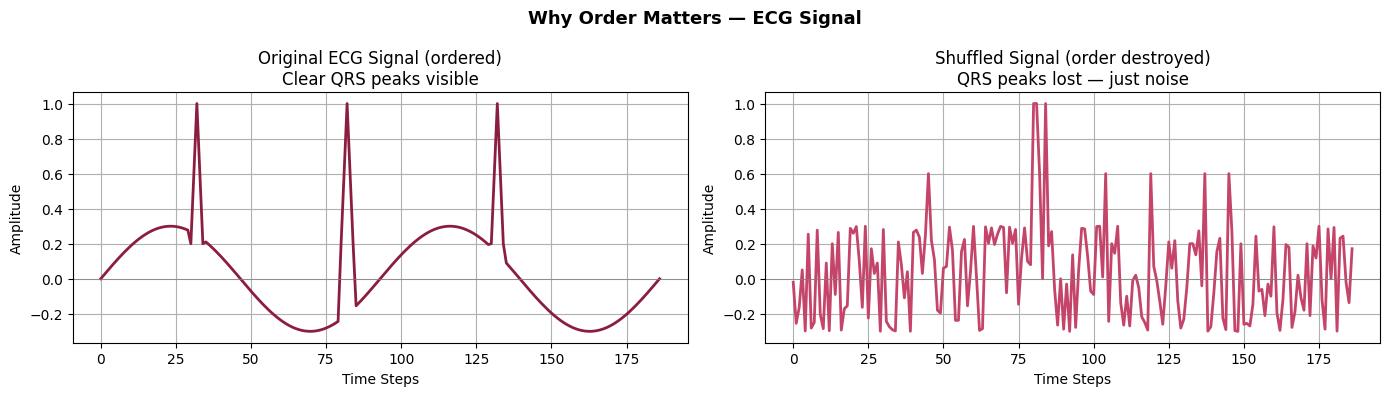

Both plots contain exactly the same 187 values.
A Dense Network sees them as identical input.
An LSTM sees the difference — because order is preserved.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate a simplified ECG-like signal (ordered)
np.random.seed(42)
t = np.linspace(0, 4 * np.pi, 187)

# Normal heartbeat pattern: sine-based with sharp QRS peak
signal = np.sin(t) * 0.3
signal[30:35] = [0.2, 0.6, 1.0, 0.6, 0.2]   # QRS complex
signal[80:85] = [0.2, 0.6, 1.0, 0.6, 0.2]
signal[130:135] = [0.2, 0.6, 1.0, 0.6, 0.2]

# Shuffled version — same values, random order
shuffled = signal.copy()
np.random.shuffle(shuffled)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Why Order Matters — ECG Signal", fontsize=13, fontweight="bold")

axes[0].plot(signal, color="#8B1E3F", linewidth=2)
axes[0].set_title("Original ECG Signal (ordered)\nClear QRS peaks visible")
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True)
axes[0].axhline(y=0, color='gray', linewidth=0.5)

axes[1].plot(shuffled, color="#C44569", linewidth=2)
axes[1].set_title("Shuffled Signal (order destroyed)\nQRS peaks lost — just noise")
axes[1].set_xlabel("Time Steps")
axes[1].set_ylabel("Amplitude")
axes[1].grid(True)
axes[1].axhline(y=0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.show()

print("Both plots contain exactly the same 187 values.")
print("A Dense Network sees them as identical input.")
print("An LSTM sees the difference — because order is preserved.")

**What the Plot Shows**

Both plots contain exactly the same 187 values — but they tell completely
different stories.

**Left — Original ECG signal:**
Three clear QRS peaks are visible at regular intervals, surrounded by the
characteristic P and T waves of a normal heartbeat. A cardiologist —
or a trained LSTM — can immediately recognize this as a normal rhythm.

**Right — Shuffled signal:**
The same 187 values, in random order. The QRS

---

## RNN — The Basic Idea

A Dense Network passes data through layers in one direction — input to output.
It has no memory between elements.

An RNN adds one key change: **a loop**.

At each time step, the RNN cell receives two inputs:
- The current element from the sequence
- The hidden state from the previous step — its memory

It combines both and produces:
- A new hidden state (passed to the next step)
- An output (used for prediction)

This loop is what makes it "recurrent" — the same cell processes every
element in the sequence, carrying memory forward each time.

```
Without memory (Dense):     x[0] → layer → output
                            x[1] → layer → output   (no connection)

With memory (RNN):          x[0] → cell → h[1] ─────────────┐
                            x[1] + h[1] → cell → h[2] ───┐  │
                            x[2] + h[2] → cell → h[3]    │  │
                                                    memory flows →
```

---

## Hidden State — RNN's Memory

The hidden state `h[t]` is a vector of numbers — typically 32, 64, or 128
values — that summarizes everything the RNN has seen up to time step t.

At each step, the RNN updates it with a simple formula:


```
h[t] = tanh( W_h × h[t-1] + W_x × x[t] + b )
↑ ↑
previous memory current input
```

- `W_h` — weights applied to the previous hidden state
- `W_x` — weights applied to the current input
- `tanh` — squashes the output to the range (-1, 1)

After processing the full sequence, `h[final]` is a compressed
representation of the entire sequence — passed to a Dense layer
for the final classification.

**Parameter sharing across time:**
The same weights (W_h, W_x, b) are used at every time step.
This is analogous to how a CNN filter is reused across all spatial positions.
It keeps the model small regardless of sequence length.


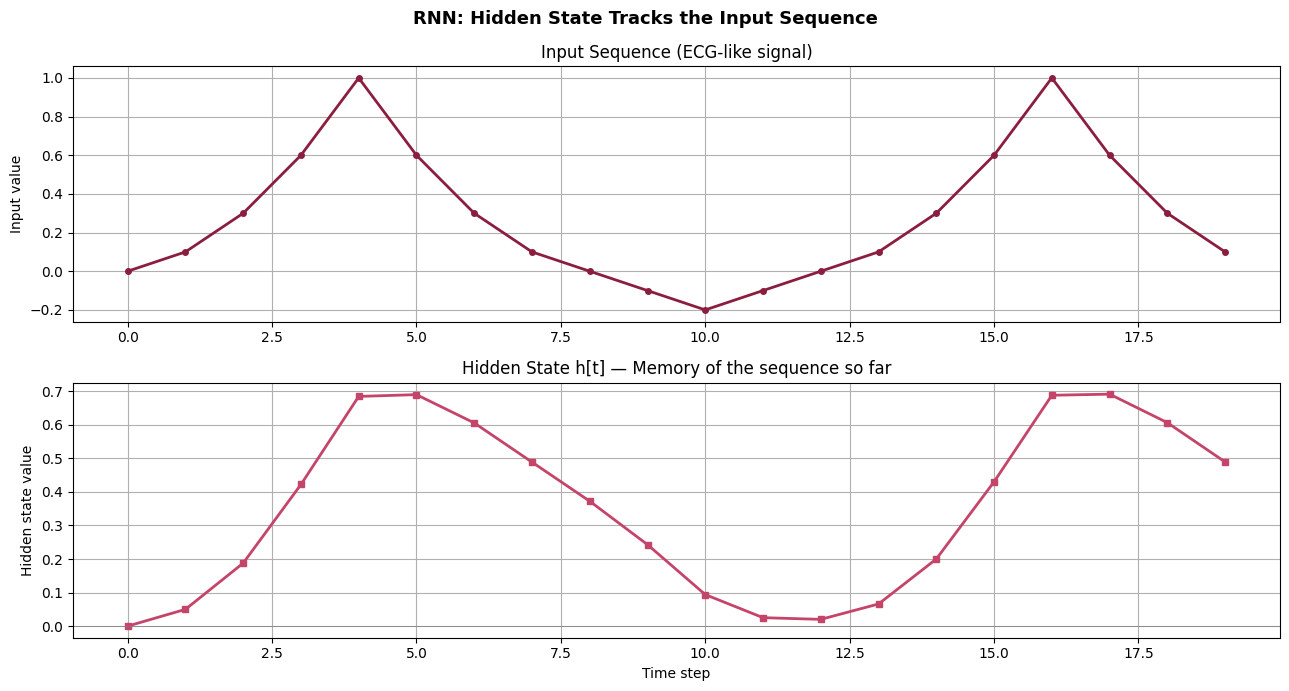

The hidden state tracks the input pattern.
At each step it reflects both the current input AND all previous inputs.

Final hidden state value: 0.4892
This single value summarizes the entire 20-step sequence.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate RNN hidden state evolution on a simple sequence
np.random.seed(42)

# Simple ECG-like sequence: 20 time steps
sequence = np.array([0.0, 0.1, 0.3, 0.6, 1.0, 0.6, 0.3, 0.1,
                     0.0, -0.1, -0.2, -0.1, 0.0, 0.1, 0.3, 0.6,
                     1.0, 0.6, 0.3, 0.1])

# Simulate hidden state update: h[t] = tanh(W_h * h[t-1] + W_x * x[t])
W_h = 0.8   # weight on previous hidden state
W_x = 0.5   # weight on current input
h = 0.0
hidden_states = []

for x_t in sequence:
    h = np.tanh(W_h * h + W_x * x_t)
    hidden_states.append(h)

hidden_states = np.array(hidden_states)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
fig.suptitle("RNN: Hidden State Tracks the Input Sequence",
             fontsize=13, fontweight="bold")

axes[0].plot(sequence, color="#8B1E3F", linewidth=2, marker="o", markersize=4)
axes[0].set_title("Input Sequence (ECG-like signal)")
axes[0].set_ylabel("Input value")
axes[0].grid(True)

axes[1].plot(hidden_states, color="#C44569", linewidth=2, marker="s", markersize=4)
axes[1].set_title("Hidden State h[t] — Memory of the sequence so far")
axes[1].set_ylabel("Hidden state value")
axes[1].set_xlabel("Time step")
axes[1].grid(True)
axes[1].axhline(y=0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

print("The hidden state tracks the input pattern.")
print("At each step it reflects both the current input AND all previous inputs.")
print(f"\nFinal hidden state value: {hidden_states[-1]:.4f}")
print("This single value summarizes the entire 20-step sequence.")

**What the Plot Shows**

**Top — Input sequence:**
A simplified ECG-like signal with two clear peaks (QRS complexes) at
steps 4 and 16, connected by a wave pattern. This is what the RNN
reads one step at a time.

**Bottom — Hidden state h[t]:**
The hidden state tracks the input pattern — it rises when the input
rises and falls when the input falls. But notice two important things:

1. **It never reaches the full input amplitude (1.0):**
   The tanh function squashes the output to (-1, 1), and the hidden
   state is a weighted combination of the input AND previous memory —
   so it smooths out sharp changes.

2. **It carries memory between peaks:**
   Even when the input drops near zero (steps 8-13), the hidden state
   does not reset to zero — it retains some memory of the first peak.
   When the second peak arrives (step 16), the hidden state responds
   differently than it did to the first peak, because it remembers
   what came before.

**The final hidden state value (step 19) summarizes the entire sequence.**
This single vector — in a real model, 64 or 128 numbers — is what gets
passed to the Dense layer for classification.

---

## The Problem with Plain RNNs — Vanishing Gradient

In theory, the hidden state carries memory across the entire sequence.
In practice, plain RNNs struggle with **long sequences**.

The problem happens during training. To update the weights, the network
uses **Backpropagation Through Time (BPTT)** — it unrolls the RNN across
all time steps and propagates the error gradient backwards from the last
step to the first.

At each step, the gradient is multiplied by the weights. If those weights
are small (less than 1), the gradient **shrinks exponentially** as it
travels back through time:



```
Step 100 ← Step 99 ← Step 98 ← ... ← Step 1
gradient × W × W × W × ... × W
= gradient × W^100 → ≈ 0 (vanishes)
```

By the time the gradient reaches the early steps, it is effectively zero.
The weights at those steps receive no meaningful update — the network
cannot learn dependencies that span many time steps.

**Result:** plain RNNs can only remember information from the last
few steps. Anything earlier is forgotten.


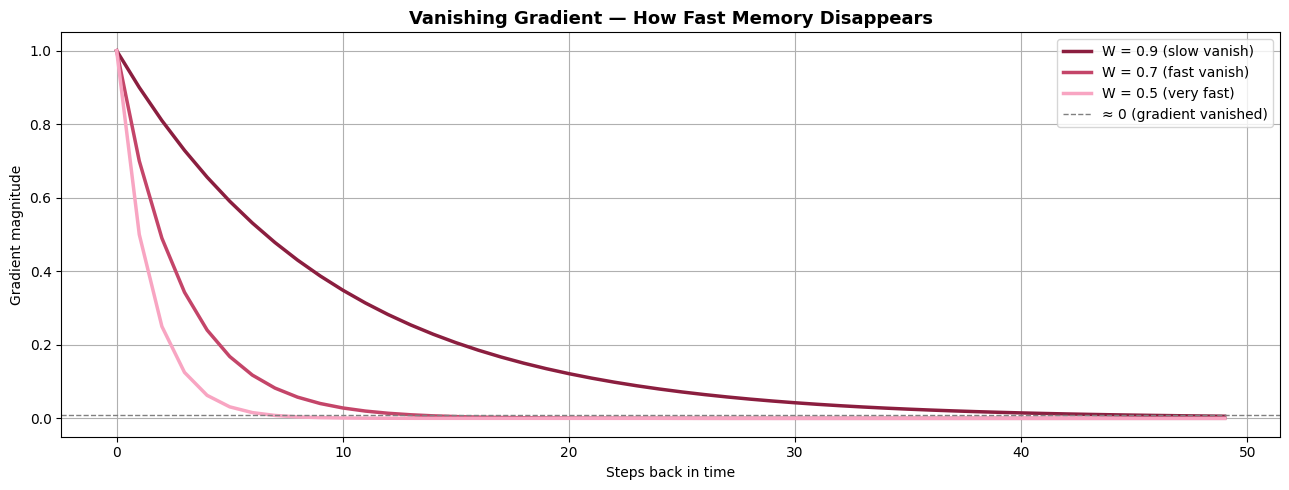

Even with W = 0.9:
  After 10 steps: gradient = 0.3487
  After 30 steps: gradient = 0.0424
  After 50 steps: gradient = 0.005154

The network effectively forgets anything more than ~10-20 steps back.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate gradient vanishing over time steps
steps = 50
weights = [0.9, 0.7, 0.5]  # different weight values
colors  = ["#8B1E3F", "#C44569", "#F8A5C2"]
labels  = ["W = 0.9 (slow vanish)", "W = 0.7 (fast vanish)", "W = 0.5 (very fast)"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_title("Vanishing Gradient — How Fast Memory Disappears",
             fontsize=13, fontweight="bold")

for w, color, label in zip(weights, colors, labels):
    gradients = [w ** t for t in range(steps)]
    ax.plot(gradients, color=color, linewidth=2.5, label=label)

ax.axhline(y=0.01, color="gray", linewidth=1,
           linestyle="--", label="≈ 0 (gradient vanished)")
ax.set_xlabel("Steps back in time")
ax.set_ylabel("Gradient magnitude")
ax.legend()
ax.grid(True)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

print("Even with W = 0.9:")
print(f"  After 10 steps: gradient = {0.9**10:.4f}")
print(f"  After 30 steps: gradient = {0.9**30:.4f}")
print(f"  After 50 steps: gradient = {0.9**50:.6f}")
print()
print("The network effectively forgets anything more than ~10-20 steps back.")

**What the Plot Shows**

All three lines start at 1.0 (full gradient at the current step) and
shrink as we look further back in time.

- **W = 0.9:** the gradient survives about 20-30 steps before
  effectively vanishing. The network can remember recent context
  but forgets anything earlier.
- **W = 0.7:** vanishes within 10-15 steps.
- **W = 0.5:** vanishes within 5-8 steps — almost no memory at all.

For an ECG signal with 187 time steps, a plain RNN with typical weights
cannot reliably connect information from the beginning of the heartbeat
to the end. The patterns that define arrhythmias — subtle changes in
wave shape across the full beat — are exactly the kind of long-range
dependency that plain RNNs fail to learn.

**This is the specific problem LSTM was designed to solve.**

---

## LSTM — Long Short-Term Memory

An LSTM solves the vanishing gradient problem by replacing the simple
hidden state with two separate memory systems:

- **Cell state (C[t])** — long-term memory: flows through the sequence
  with minimal modification, like a conveyor belt carrying information
  across many time steps
- **Hidden state (h[t])** — short-term memory: what the LSTM outputs
  at each step, used for prediction

The key innovation is **gates** — learned mechanisms that control what
information is kept, forgotten, or added at each step.

| Gate | Function | Output range |
|------|----------|-------------|
| **Forget gate** | Decides what to erase from long-term memory | 0 (forget all) → 1 (keep all) |
| **Input gate** | Decides what new information to add | 0 (add nothing) → 1 (add fully) |
| **Output gate** | Decides what to output from memory | 0 (output nothing) → 1 (output fully) |

Each gate is a small neural network — it learns from data when to
remember and when to forget. This is the key difference from a plain RNN,
which has no control over what it keeps or discards.

---

### LSTM Gates — Step by Step

**Step 1 — Forget Gate**
Looks at the current input and the previous hidden state.
Outputs a number between 0 and 1 for each value in the cell state.
- 0 → completely forget this
- 1 → completely keep this

Example: reading a new sentence, the LSTM forgets the subject of the
previous sentence because it is no longer relevant.

**Step 2 — Input Gate**
Decides which new information to write into the cell state.
Two parts:
- Input gate: how much of the new information to add
- Candidate values: what new information to potentially add

**Step 3 — Update Cell State**
Combines forget and input:



```
C[t] = forget_gate × C[t-1] + input_gate × candidate
↑ ↑
old memory (partially erased) new information (partially added)
```

**Step 4 — Output Gate**
Decides what to output as the hidden state h[t] —
a filtered version of the cell state, used for prediction.

**Why this solves vanishing gradients:**
The cell state C[t] can flow through many time steps with only small,
controlled modifications from the gates. Gradients flowing back through
the cell state do not shrink exponentially — they can reach early time
steps intact, allowing the LSTM to learn long-range dependencies.


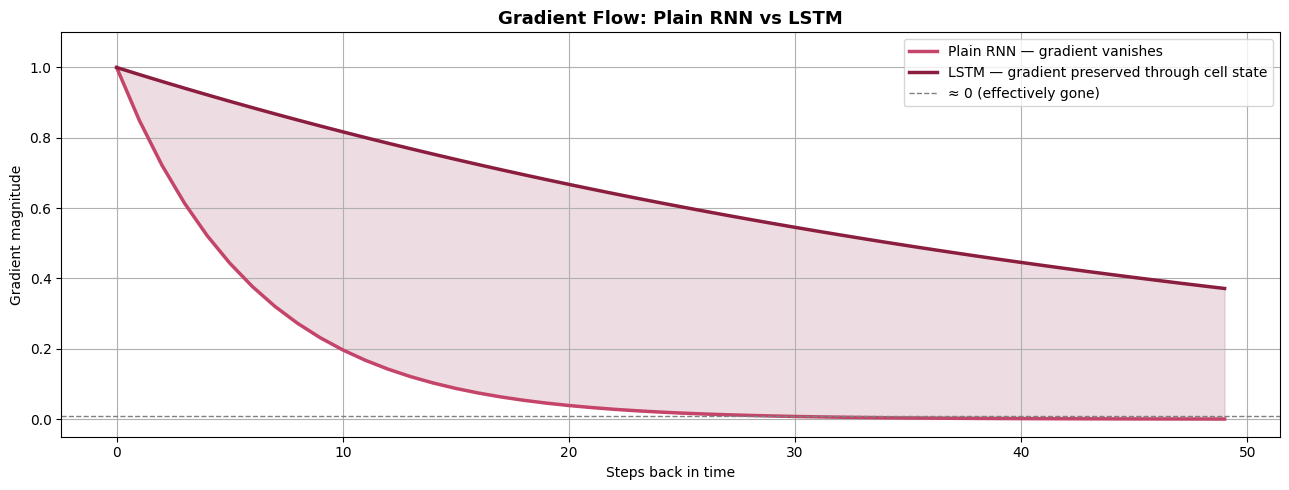

Plain RNN after 30 steps: 0.00763  ← effectively zero
LSTM after 30 steps:       0.54548  ← still meaningful


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate LSTM vs RNN gradient flow
steps  = 50
colors = {"RNN": "#C44569", "LSTM": "#8B1E3F"}

# RNN: gradient multiplied by weight at each step (vanishes)
rnn_grad = [0.85 ** t for t in range(steps)]

# LSTM: cell state gradient is protected — stays close to 1
# (simplified: slight decay only from gate leakage)
lstm_grad = [max(0.98 ** t, 0.02) for t in range(steps)]

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_title("Gradient Flow: Plain RNN vs LSTM",
             fontsize=13, fontweight="bold")

ax.plot(rnn_grad,  color=colors["RNN"],  linewidth=2.5,
        label="Plain RNN — gradient vanishes")
ax.plot(lstm_grad, color=colors["LSTM"], linewidth=2.5,
        label="LSTM — gradient preserved through cell state")

ax.axhline(y=0.01, color="gray", linewidth=1,
           linestyle="--", label="≈ 0 (effectively gone)")
ax.fill_between(range(steps), rnn_grad, lstm_grad,
                alpha=0.15, color="#8B1E3F")

ax.set_xlabel("Steps back in time")
ax.set_ylabel("Gradient magnitude")
ax.set_ylim(-0.05, 1.1)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

print("Plain RNN after 30 steps:", f"{0.85**30:.5f}  ← effectively zero")
print("LSTM after 30 steps:      ", f"{0.98**30:.5f}  ← still meaningful")

**What the Plot Shows**

Both lines start at 1.0 — full gradient at the current time step.
As we look further back in time, the gradients behave very differently.

**Plain RNN (light pink):**
The gradient drops sharply — by step 20 it is near zero, and by step 30
it has completely vanished. The network receives no meaningful weight
update from anything more than ~20 steps back. For a 187-step ECG signal,
this means the RNN only "remembers" the last portion of the heartbeat —
the early wave patterns that define the beat shape are invisible to it.

**LSTM (dark red):**
The gradient decays very slowly because it flows through the cell state,
which is protected by the gates. Even at step 50, a meaningful gradient
signal remains. The shaded area between the two lines shows exactly
how much more information the LSTM preserves compared to a plain RNN.

**Why the cell state protects gradients:**
At each step, the forget gate multiplies the cell state by a value close
to 1 (keep most information) rather than by the full weight matrix.
This controlled, near-identity update prevents the exponential shrinking
that destroys gradients in plain RNNs.

For the ECG classification task — where the full 187-step heartbeat
shape matters — this difference is decisive.

---

## GRU — Gated Recurrent Unit

The GRU is a simplified version of the LSTM introduced in 2014.
It achieves similar performance with fewer parameters by merging
the LSTM's three gates into two:

| | LSTM | GRU |
|--|------|-----|
| Gates | Forget + Input + Output | Reset + Update |
| Memory | Cell state + Hidden state | Hidden state only |
| Parameters | More | Fewer (~25% less) |
| Training speed | Slower | Faster |
| Performance | Slightly better on long sequences | Comparable on most tasks |

**Reset gate:** decides how much of the previous hidden state to forget
when computing the new candidate hidden state.

**Update gate:** decides how much of the old hidden state to keep
vs how much to replace with new information — combines the LSTM's
forget and input gates into one.

### When to use LSTM vs GRU?

- **LSTM:** long sequences where long-range dependencies matter,
  when you have enough data and compute time
- **GRU:** faster training needed, smaller datasets, sequence length
  is moderate — often matches LSTM performance at lower cost

For the ECG dataset (187 steps), either works well.
I use LSTM in the Hands-On Lab because it is the more established
architecture and the performance difference is small here.

---

## Embeddings — Turning Words into Vectors

Embeddings are relevant when the input is **text** — words, characters,
or tokens. They are not used in the ECG task (which uses raw numbers),
but they are a core component of any LSTM applied to text data.

**The problem with text:**
A neural network cannot process words directly — it needs numbers.
The naive approach is one-hot encoding: a vector of zeros with a 1
at the word's position in the vocabulary.

For a vocabulary of 10,000 words:
- "cat" → [0, 0, 0, 1, 0, 0, ..., 0]  (10,000 numbers, almost all zero)
- "dog" → [0, 0, 0, 0, 1, 0, ..., 0]  (10,000 numbers, almost all zero)

This is wasteful and tells the model nothing about meaning —
"cat" and "dog" are equally distant from each other as "cat" and "airplane."

**The solution — Embeddings:**
An Embedding layer learns a dense vector (typically 64-256 numbers)
for each word, where similar words end up with similar vectors:


```
"cat" → [0.2, 0.8, -0.1, 0.4, ...] (64 numbers)
"dog" → [0.3, 0.7, -0.2, 0.5, ...] (similar to cat)
"car" → [-0.5, 0.1, 0.9, -0.3, ...] (different from cat/dog)
```

These vectors are learned during training — the model discovers
which words are semantically similar by how they are used in context.
The Embedding layer output is then fed into the LSTM one word at a time.

**In the ECG task:** the input is already numerical (187 float values),
so no embedding is needed — the signal goes directly into the LSTM.


---

## Summary — Learning Notebook

| Concept | Key Takeaway |
|---------|-------------|
| Sequential data | Order carries meaning — shuffling destroys the information |
| Different data → different architectures | Tabular → Dense, Images → CNN, Sequences → RNN/LSTM |
| RNN | Processes one element at a time, passes hidden state forward as memory |
| Hidden state | Compressed summary of everything seen so far — updated at each step |
| Backpropagation Through Time | Gradients flow backwards through all time steps during training |
| Vanishing gradient | Gradients shrink exponentially — plain RNN forgets early steps |
| LSTM | Three gates control what to forget, add, and output — cell state protects gradients |
| GRU | Simplified LSTM — two gates, fewer parameters, comparable performance |
| Embeddings | Learned dense vectors for text tokens — not needed for numerical sequences |

**Architecture decision for today's task:**

| Data | Architecture | Why |
|------|-------------|-----|
| ECG heartbeat (187 time steps) | LSTM | Long sequence — needs protected gradient flow |
| Melanoma images (128×128) | CNN | Spatial structure — patterns shift across the image |
| Cardiovascular tabular (12 features) | Dense Network | Independent features — no order or spatial structure |

**Next:** Hands-On Lab — applying LSTM and plain RNN to the MIT-BIH
ECG dataset and comparing their performance on heartbeat classification.